In [148]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.scale_bar import ScaleBar, scale_bar


In [149]:
skolky_venkov = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_venkov.parquet")
skolky_mesto = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_mesto.parquet")

skolky_body = pd.concat(
    [skolky_venkov, skolky_mesto]
)
skolky_body=skolky_body.drop(columns=["index_right"])


In [150]:
#skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")
obce_polygony = gpd.read_file("geometrie/obce_slbd.geojson").to_crs(5514)
obce_polygony = obce_polygony[["geometry","celkem", "Kód_obce"]]

In [151]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



In [152]:
obce_skolky= gpd.sjoin(skolky_body,obce_polygony)
#obce_skolky = gpd.sjoin(obce_polygony,skolky_body)

In [153]:
bins = [0, 3000,float('inf')]
labels = [1, 2]

obce_skolky["size_category"] = pd.cut(
    obce_skolky["celkem_left"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


In [154]:
obce_venkov = obce_skolky[obce_skolky["size_category"]==1]
obce_mesto = obce_skolky[obce_skolky["size_category"]==2]


In [155]:
#obce_venkov.to_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_venkov.parquet")
#obce_mesto.to_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_mesto.parquet")

In [156]:
avg_price = obce_skolky.groupby('Kód_obce_left').agg({
    'monthly_fe': 'mean',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce_left','monthly_fe']}
})
avg = avg_price.pivot_table(
    values="monthly_fe",
    index="ORP",
    columns="size_category",
    aggfunc="mean"
).round()

print(avg.mean(axis=0).round())
avg



size_category
1    418.0
2    588.0
dtype: float64


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_96554/3680198695.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  avg = avg_price.pivot_table(


size_category,1,2
ORP,,
1100.0,NaN,1204.0
2101.0,497.0,737.0
2102.0,628.0,817.0
2103.0,1049.0,1059.0
2104.0,370.0,651.0
...,...,...
8118.0,350.0,500.0
8119.0,424.0,614.0
8120.0,306.0,500.0


In [157]:
std_price = obce_skolky.groupby('Kód_obce_left').agg({
    'monthly_fe': 'std',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})

std = std_price.pivot_table(
    values="monthly_fe",
    index="ORP",
    columns="size_category",
    aggfunc="mean"
).round()
print(std.mean(axis=0).round())
std


size_category
1    31.0
2    23.0
dtype: float64


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_96554/2108562358.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std = std_price.pivot_table(


size_category,1,2
ORP,,
1100.0,NaN,223.0
2101.0,NaN,0.0
2102.0,NaN,0.0
2103.0,NaN,3.0
2105.0,NaN,0.0
...,...,...
8115.0,NaN,0.0
8117.0,NaN,12.0
8118.0,NaN,0.0


In [158]:
# average fee for size categories
obce_skolky.groupby('size_category')['monthly_fe'].mean()

/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_96554/1971207276.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obce_skolky.groupby('size_category')['monthly_fe'].mean()


size_category
1    436.707955
2    738.465251
Name: monthly_fe, dtype: float64

In [159]:
tables_by_orp = {}

for orp, df_orp in obce_skolky.groupby("Název_ORP"):

    size_counts_total = df_orp.groupby("size_category").size()
    size_counts = df_orp[df_orp["monthly_fe"].notna()].groupby("size_category").size()

    table = pd.DataFrame({
        "total_count": size_counts_total,
        "count": size_counts
    })

    table["percentage"] = table["count"] / table["total_count"] * 100
    table["average_fee"] = df_orp.groupby("size_category")["monthly_fe"].mean()
    table["median_fee"] = df_orp.groupby("size_category")["monthly_fe"].median()
    table["std_fee"] = df_orp.groupby("size_category")["monthly_fe"].std()

    tables_by_orp[orp] = table.round()


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_96554/198270040.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts_total = df_orp.groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_96554/198270040.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts = df_orp[df_orp["monthly_fe"].notna()].groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_96554/198270040.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

In [160]:
tables_by_orp["Tachov"]


,total_count,count,percentage,average_fee,median_fee,std_fee
size_category,,,,,,
1,12,12,100.0,391.0,394.0,96.0
2,7,7,100.0,956.0,1000.0,76.0


In [161]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/ORP.geojson")
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})

In [162]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

table = pd.DataFrame({

'average_fee': skolky_body.groupby('Název_ORP')['monthly_fe'].mean().round(),
'std_fee': skolky_body.groupby('Název_ORP')['monthly_fe'].std().round()})

table.sort_values('average_fee', ascending=False).head(20)

,average_fee,std_fee
Název_ORP,,
Hlavní město Praha,1206.0,223.0
Říčany,1174.0,289.0
Brandýs nad Labem-Stará Boleslav,1026.0,307.0
Český Brod,948.0,235.0
Černošice,865.0,177.0
Brno,862.0,143.0
Neratovice,798.0,165.0
Lysá nad Labem,751.0,108.0
Liberec,735.0,159.0


In [163]:
orp = orp_polygony.merge(table, left_on ="naz_orp_p", right_index=True)

orp["average_fee"] = orp["average_fee"].astype(int)

<Axes: >

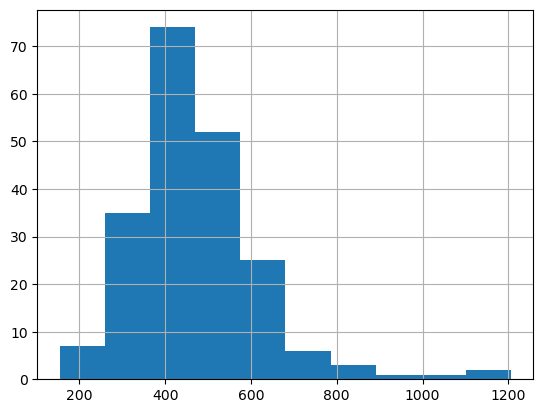

In [164]:
orp.average_fee.hist()

In [165]:
vmin = orp["average_fee"].min()
vmax = orp["average_fee"].max()

In [166]:
bins = [339, 440, 552, 693,945 ,1365]
labels = (
    [f"≤ {int(bins[0])}"] +
    [f"{int(bins[i])} — {int(bins[i+1])}"
     for i in range(len(bins) - 1)]
)


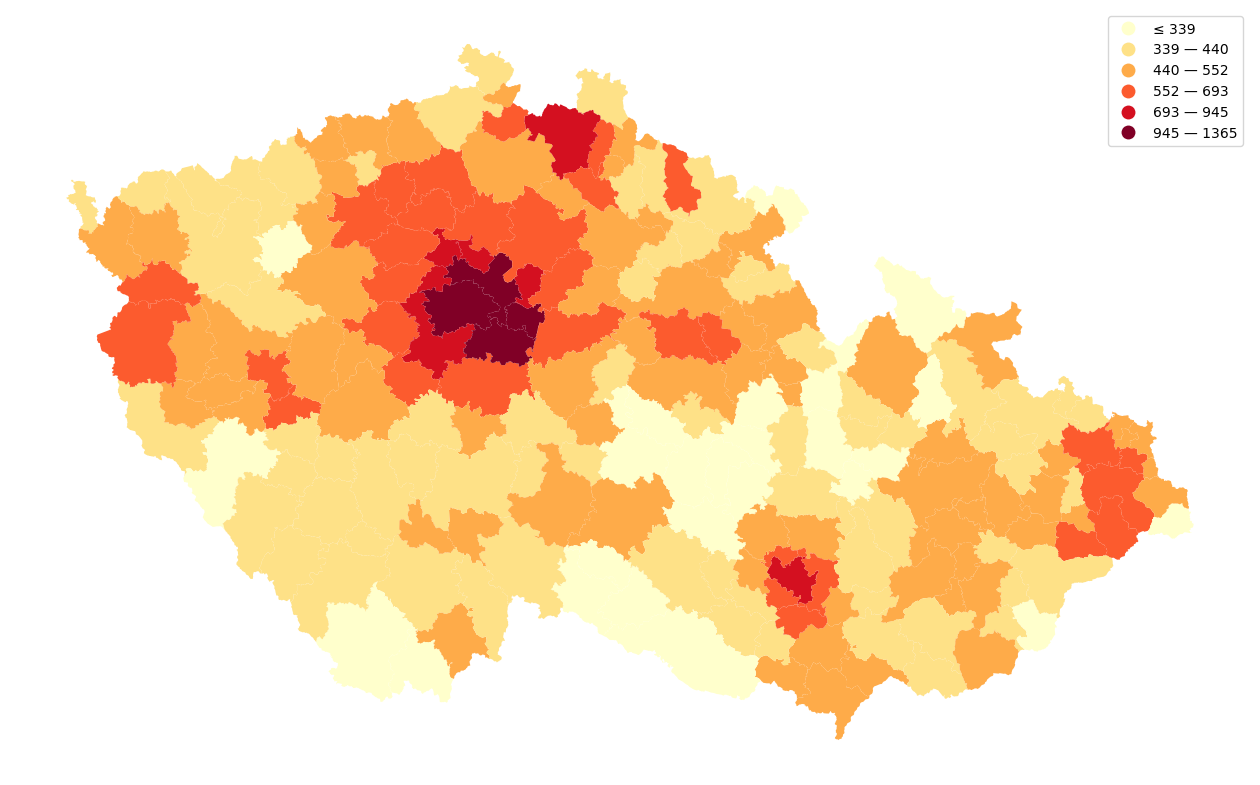

In [167]:
orp.plot(
    column="average_fee",
    figsize=(16, 10),
    cmap="YlOrRd",
    legend=True,
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    legend_kwds={"labels": labels},

).set_axis_off()


In [168]:
tables_by_size = {}

for size_cat in obce_skolky["size_category"].unique():
    sub = obce_skolky[obce_skolky["size_category"] == size_cat]
    fee = sub[sub["monthly_fe"].notna()]

    table = pd.DataFrame({
       "average_fee":sub.groupby("Název_ORP")["monthly_fe"].mean().round(),
   "std_fee": sub.groupby("Název_ORP")["monthly_fe"].std().round()})

    tables_by_size[size_cat] = table.sort_values( "average_fee",ascending=False)


In [169]:
tables_by_size[1]

,average_fee,std_fee
Název_ORP,,
Říčany,1112.0,266.0
Brandýs nad Labem-Stará Boleslav,1049.0,330.0
Český Brod,1029.0,196.0
Černošice,843.0,156.0
Lysá nad Labem,787.0,156.0
...,...,...
Konice,221.0,108.0
Jablunkov,115.0,72.0
Podbořany,112.0,155.0


In [170]:
tables_by_size[2]

,average_fee,std_fee
Název_ORP,,
Říčany,1365.0,288.0
Hlavní město Praha,1206.0,223.0
Neratovice,1089.0,29.0
Brandýs nad Labem-Stará Boleslav,979.0,257.0
Turnov,971.0,76.0
...,...,...
Jablunkov,362.0,50.0
Kaplice,359.0,4.0
Znojmo,350.0,71.0


In [171]:
mesto = orp_polygony.merge(tables_by_size[2], left_on ="naz_orp_p", right_index=True)
venkov = orp_polygony.merge(tables_by_size[1], left_on ="naz_orp_p", right_index=True)


In [172]:
kraje_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/kraje.geojson")
kraje_polygony = kraje_polygony.to_crs(5514)

In [173]:
tables_by_size = {}

for size_cat in obce_skolky["size_category"].unique():
    sub = obce_skolky[obce_skolky["size_category"] == size_cat]
    fee = sub[sub["monthly_fe"].notna()]

    table = pd.DataFrame({
"average_fee": (sub.groupby("Kraj")["monthly_fe"].mean().round()).astype(int),
#"std_fee": sub.groupby("Kraj")["monthly_fe"].std().round()
})

    tables_by_size[size_cat] = table
table

,average_fee
Kraj,
Hlavní město Praha,1206
Jihomoravský kraj,750
Jihočeský kraj,434
Karlovarský kraj,571
Kraj Vysočina,610
Královéhradecký kraj,584
Liberecký kraj,728
Moravskoslezský kraj,602
Olomoucký kraj,619


In [174]:
kraje = kraje_polygony.merge(table, left_on ="NAZEV", right_index=True)


In [175]:
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
from matplotlib import patheffects as PathEffects

In [176]:
ScaleBar.set_size(size="lg")

In [186]:
kraje['NAZEV'] = kraje['NAZEV'].replace({
    "Hlavní město Praha": "Prague",
    "Středočeský kraj": "Central Bohemian Region",
    "Jihočeský kraj": "South Bohemian Region",
    "Plzeňský kraj": "Plzeň Region",
    "Karlovarský kraj": "Karlovy Vary Region",
    "Ústecký kraj": "Ústí nad Labem Region",
    "Liberecký kraj": "Liberec Region",
    "Královéhradecký kraj": "Hradec Králové Region",
    "Pardubický kraj": "Pardubice Region",
    "Kraj Vysočina": "Vysočina Region",
    "Jihomoravský kraj": "South Moravian Region",
    "Olomoucký kraj": "Olomouc Region",
    "Zlínský kraj": "Zlín Region",
    "Moravskoslezský kraj": "Moravian-Silesian Region",
})


In [191]:
kraje['label'] = kraje['NAZEV'].replace({
    "Central Bohemian Region": "Central Bohemian\nRegion",
    "South Bohemian Region": "South Bohemian\nRegion",
    "South Moravian Region": "South Moravian\nRegion",
    "Moravian-Silesian Region": "Moravian-Silesian\nRegion",
    "Hradec Králové Region": "Hradec Králové\nRegion",
    "Ústí nad Labem Region": "Ústí nad Labem\nRegion",
    "Karlovy Vary Region": "Karlovy Vary\nRegion",
     "Olomouc Region": "Olomouc\nRegion",

})


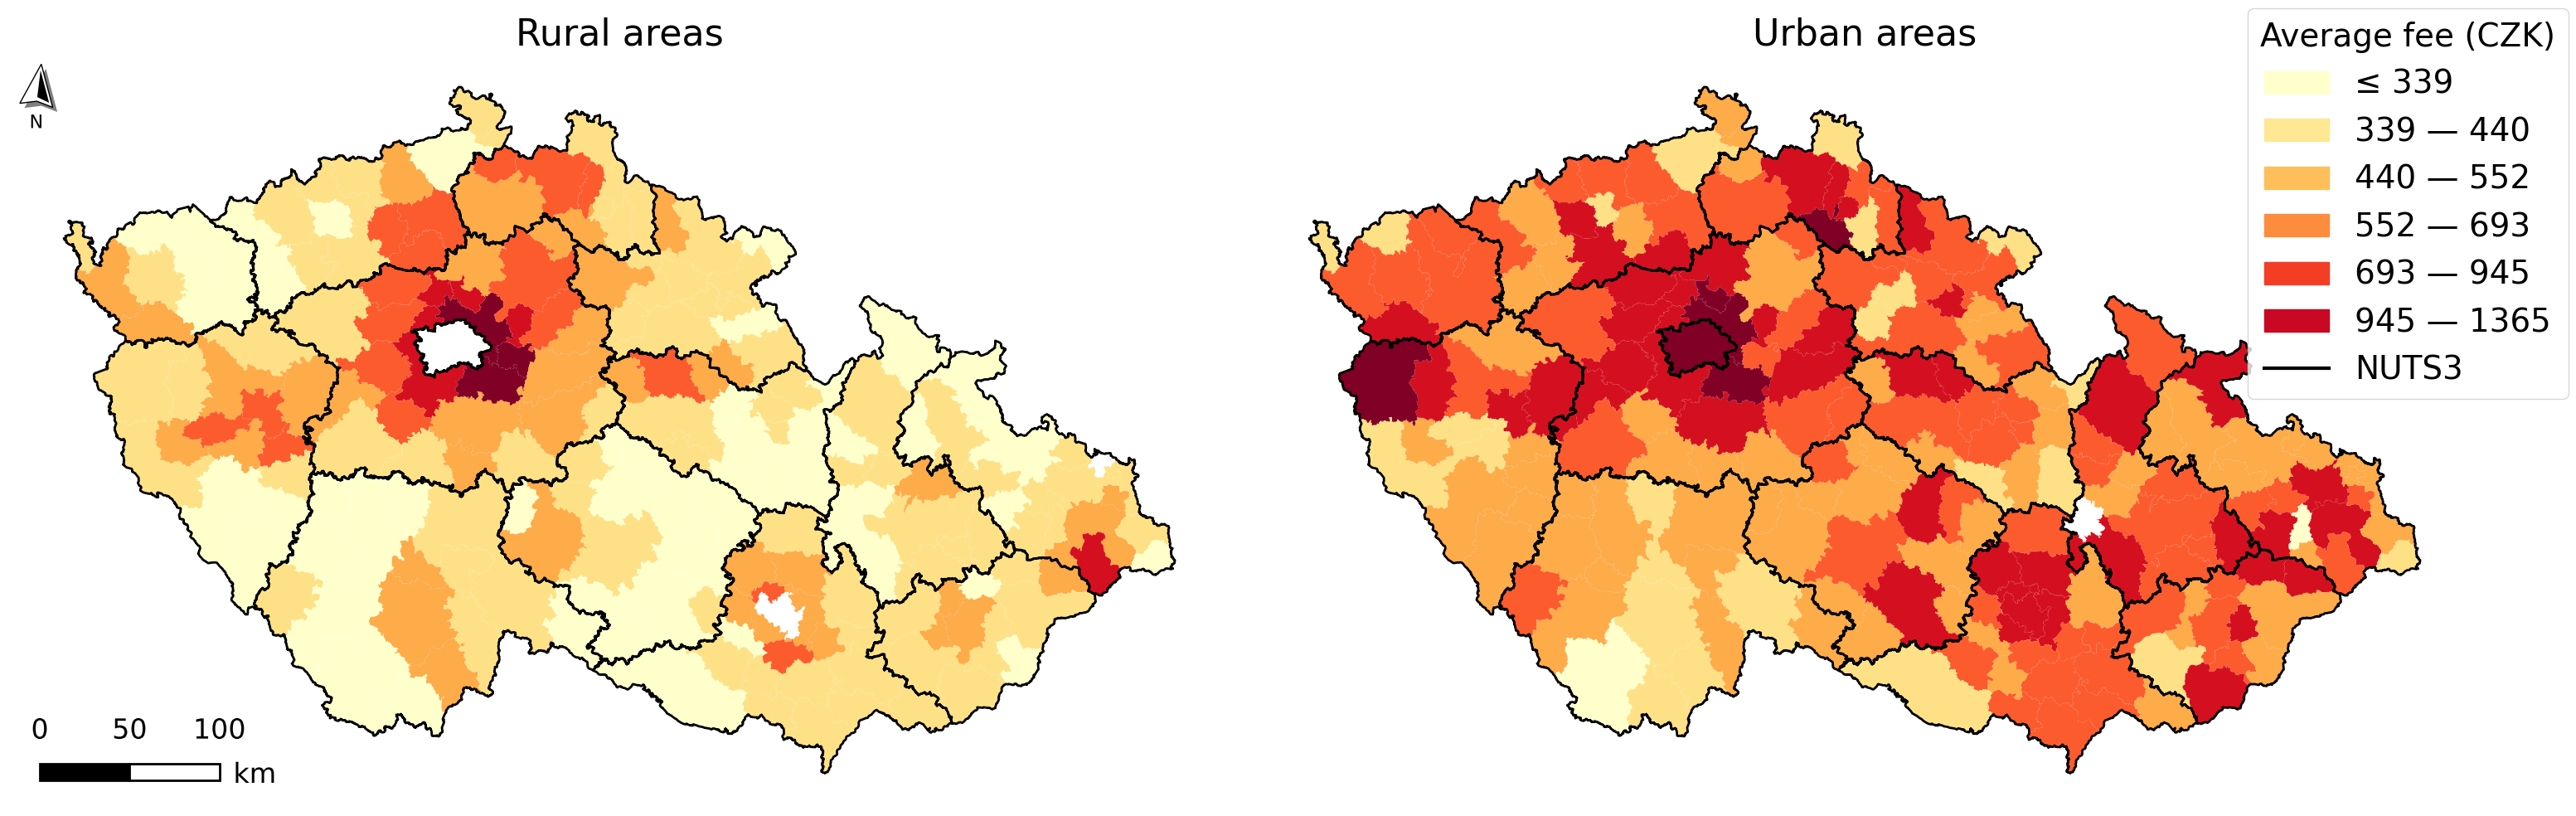

In [ ]:
offsets = {
    "Olomouc\nRegion": (20000, -20000),    # move 2 km right, 2 km down
    "Moravian-Silesian\nRegion": (0,-7000),    # 3 km right, 1.5 km down
    "Central Bohemian\nRegion": (-25000, -30000),  # 2.5 km left, 2 km up
}

fig, axes = plt.subplots(1, 2, figsize=(32, 10))


venkov.plot(
    column="average_fee",
    ax=axes[0],
    legend=False,
    cmap="YlOrRd",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    legend_kwds={"labels": labels,    "fontsize": 20, "markerscale": 1.5},
    missing_kwds={"color": "white"},
)
kraje.plot(
    ax=axes[0],
    facecolor="none",
    edgecolor="black",
        linewidth=2)
"""
for idx, row in kraje.iterrows():
    x, y = row.geometry.representative_point().coords[0]

    # Apply offset if exists
    dx, dy = offsets.get(row['label'], (0, 0))
    x += dx
    y += dy

    label = row['label']  # your multi-line label
    txt = axes[0].text(
        x, y,
        label,
        ha='center',
        va='center',
        fontsize=15,
        color='black',
        path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")],

    )
"""
axes[0].set_title("Rural areas",fontsize=32)
axes[0].set_axis_off()

# Město
mesto.plot(
    column="average_fee",
    ax=axes[1],
    cmap="YlOrRd",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    legend=False,               
    missing_kwds={"color": "white"},
    
)

# Create a manual legend using your bins and labels
patches = [mpatches.Patch(color=plt.cm.YlOrRd(i / len(bins)), label=label) 
           for i, label in enumerate(labels)]
line_patch = Line2D([0], [0], color='black', linewidth=3, label='NUTS3')
patches.append(line_patch)

axes[1].legend(handles=patches, 
                fontsize=28, 
                title="Average fee (CZK)", 
                title_fontsize=28,    
                loc='center left',          
                bbox_to_anchor=(0.8, 0.8)  )

kraje.plot(
    ax=axes[1],
    facecolor="none",
    edgecolor="black",
    linewidth=2)

"""
for idx, row in kraje.iterrows():
    x, y = row.geometry.representative_point().coords[0]

    # Apply offset if exists
    dx, dy = offsets.get(row['label'], (0, 0))
    x += dx
    y += dy

    label = row['label']  # your multi-line label
    txt = axes[1].text(
        x, y,
        label,
        ha='center',
        va='center',
        fontsize=15,
        color='black',
        path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")],

    )
"""   

axes[1].set_axis_off()
axes[1].set_title("Urban areas",fontsize=32)

scale_bar(
    axes[0], location="lower left", style="boxes", bar={"projection": kraje.crs, "unit": "km"}
)
north_arrow(
    axes[0], location="upper left", rotation={"crs": kraje.crs, "reference": "center"}
)
plt.tight_layout()




<Axes: >

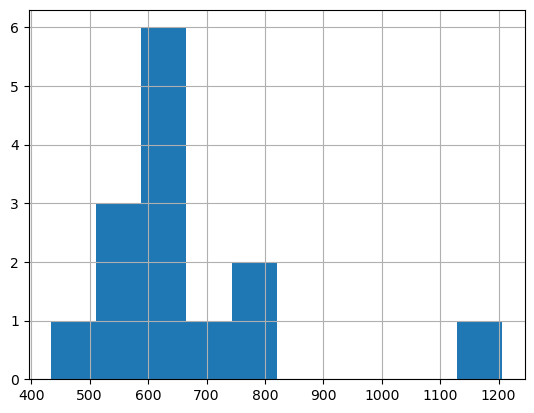

In [132]:
kraje["average_fee"].hist()

In [133]:
bins = [434, 588, 623, 657,750, 785,1206]
labels = (
    [f"≤ {int(bins[0])}"] +
    [f"{int(bins[i])} — {int(bins[i+1])}"
     for i in range(len(bins) - 1)]
)


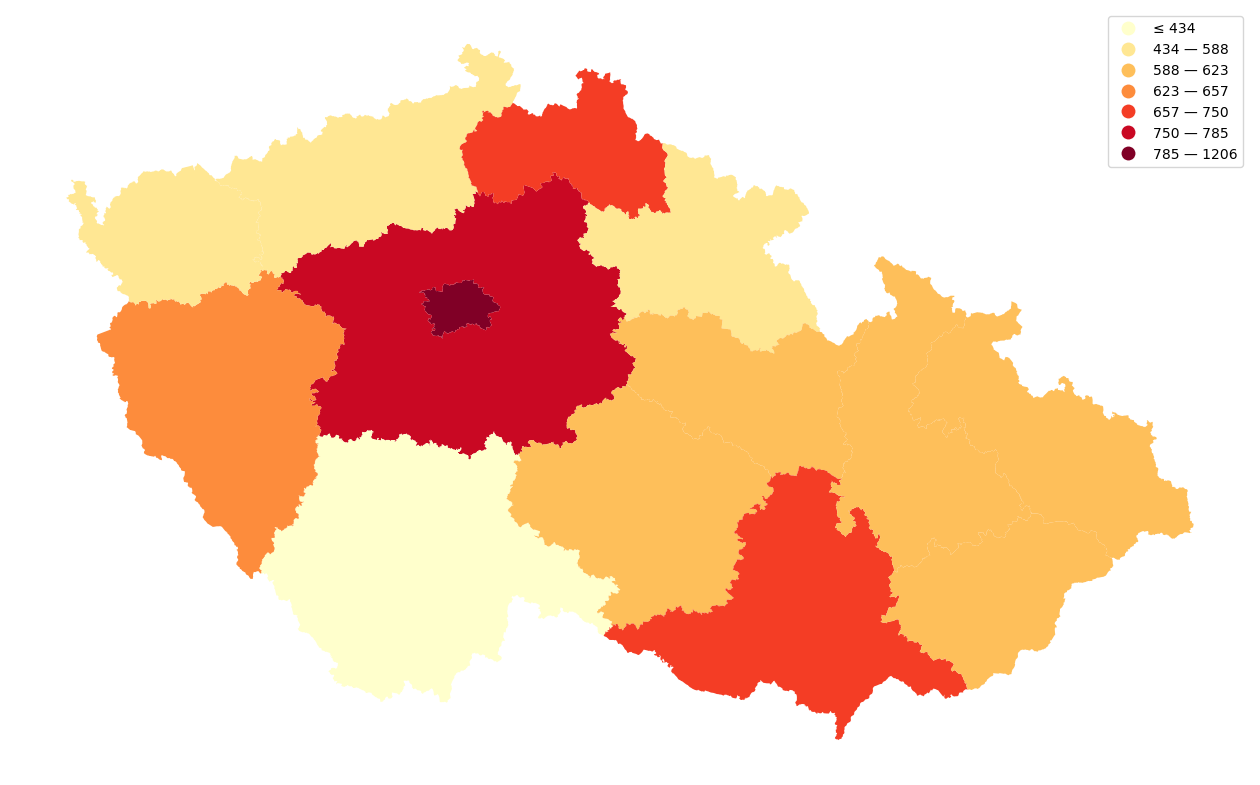

In [134]:
kraje.plot(
    column="average_fee",
    figsize=(16, 10),
    cmap="YlOrRd",
    legend=True,
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    legend_kwds={"labels": labels},

).set_axis_off()


In [135]:
venkov = tables_by_size[1].rename(columns={"average_fee":"Rural areas","std_fee":"std_fee_v"})
mesto = tables_by_size[2].rename(columns={"average_fee":"Urban areas","std_fee":"std_fee_m"})

In [136]:
mesto["Urban areas"] = mesto["Urban areas"].astype(int)
venkov["Rural areas"] = venkov["Rural areas"].astype(int)

In [137]:
kraje_ceny = pd.concat([venkov,mesto], axis=1)
kraje_ceny

,Rural areas,Urban areas
Kraj,,
Jihomoravský kraj,423.0,750
Jihočeský kraj,363.0,434
Karlovarský kraj,382.0,571
Kraj Vysočina,322.0,610
Královéhradecký kraj,412.0,584
Liberecký kraj,462.0,728
Moravskoslezský kraj,386.0,602
Olomoucký kraj,350.0,619
Pardubický kraj,369.0,623


In [138]:
print(kraje_ceny["Rural areas"].mean())
print(kraje_ceny["Urban areas"].mean())

413.46153846153845
669.0


In [139]:

kraje_ceny = kraje_ceny.astype("Int64").T
kraje_ceny.style.background_gradient(axis=1)

Kraj,Jihomoravský kraj,Jihočeský kraj,Karlovarský kraj,Kraj Vysočina,Královéhradecký kraj,Liberecký kraj,Moravskoslezský kraj,Olomoucký kraj,Pardubický kraj,Plzeňský kraj,Středočeský kraj,Zlínský kraj,Ústecký kraj,Hlavní město Praha
Rural areas,423,363,382,322,412,462,386,350,369,432,644,405,425,
Urban areas,750,434,571,610,584,728,602,619,623,657,785,609,588,1206


In [142]:
kraje_ceny.to_markdown()

'|             |   South Moravian Region |   South Bohemian Region |   Karlovy Vary Region |   Vysočina Region |   Hradec Králové Region |   Liberec Region |   Moravian-Silesian Region |   Olomouc Region |   Pardubice Region |   Plzeň Region |   Central Bohemian Region |   Zlín Region |   Ústí nad Labem Region | Prague   |\n|:------------|------------------------:|------------------------:|----------------------:|------------------:|------------------------:|-----------------:|---------------------------:|-----------------:|-------------------:|---------------:|--------------------------:|--------------:|------------------------:|:---------|\n| Rural areas |                     423 |                     363 |                   382 |               322 |                     412 |              462 |                        386 |              350 |                369 |            432 |                       644 |           405 |                     425 | <NA>     |\n| Urban areas |         

In [ ]:
kraje_ceny = kraje_ceny.rename(columns={
    "Hlavní město Praha": "Prague",
    "Středočeský kraj": "Central Bohemian Region",
    "Jihočeský kraj": "South Bohemian Region",
    "Plzeňský kraj": "Plzeň Region",
    "Karlovarský kraj": "Karlovy Vary Region",
    "Ústecký kraj": "Ústí nad Labem Region",
    "Liberecký kraj": "Liberec Region",
    "Královéhradecký kraj": "Hradec Králové Region",
    "Pardubický kraj": "Pardubice Region",
    "Kraj Vysočina": "Vysočina Region",
    "Jihomoravský kraj": "South Moravian Region",
    "Olomoucký kraj": "Olomouc Region",
    "Zlínský kraj": "Zlín Region",
    "Moravskoslezský kraj": "Moravian-Silesian Region",
})


In [ ]:
kraje_ceny = kraje_ceny.rename(columns={

In [141]:
kraje_ceny

Kraj,South Moravian Region,South Bohemian Region,Karlovy Vary Region,Vysočina Region,Hradec Králové Region,Liberec Region,Moravian-Silesian Region,Olomouc Region,Pardubice Region,Plzeň Region,Central Bohemian Region,Zlín Region,Ústí nad Labem Region,Prague
Rural areas,423,363,382,322,412,462,386,350,369,432,644,405,425,<NA>
Urban areas,750,434,571,610,584,728,602,619,623,657,785,609,588,1206


In [94]:
ceny = kraje_ceny.drop(columns="Středočeský kraj")

In [95]:
ceny.mean(axis=1)

Rural areas        394.25
Urban areas    660.076923
dtype: Float64

In [96]:
mesto = kraje_polygony.merge(tables_by_size[2], left_on ="NAZEV", right_index=True)
venkov = kraje_polygony.merge(tables_by_size[1], left_on ="NAZEV", right_index=True)


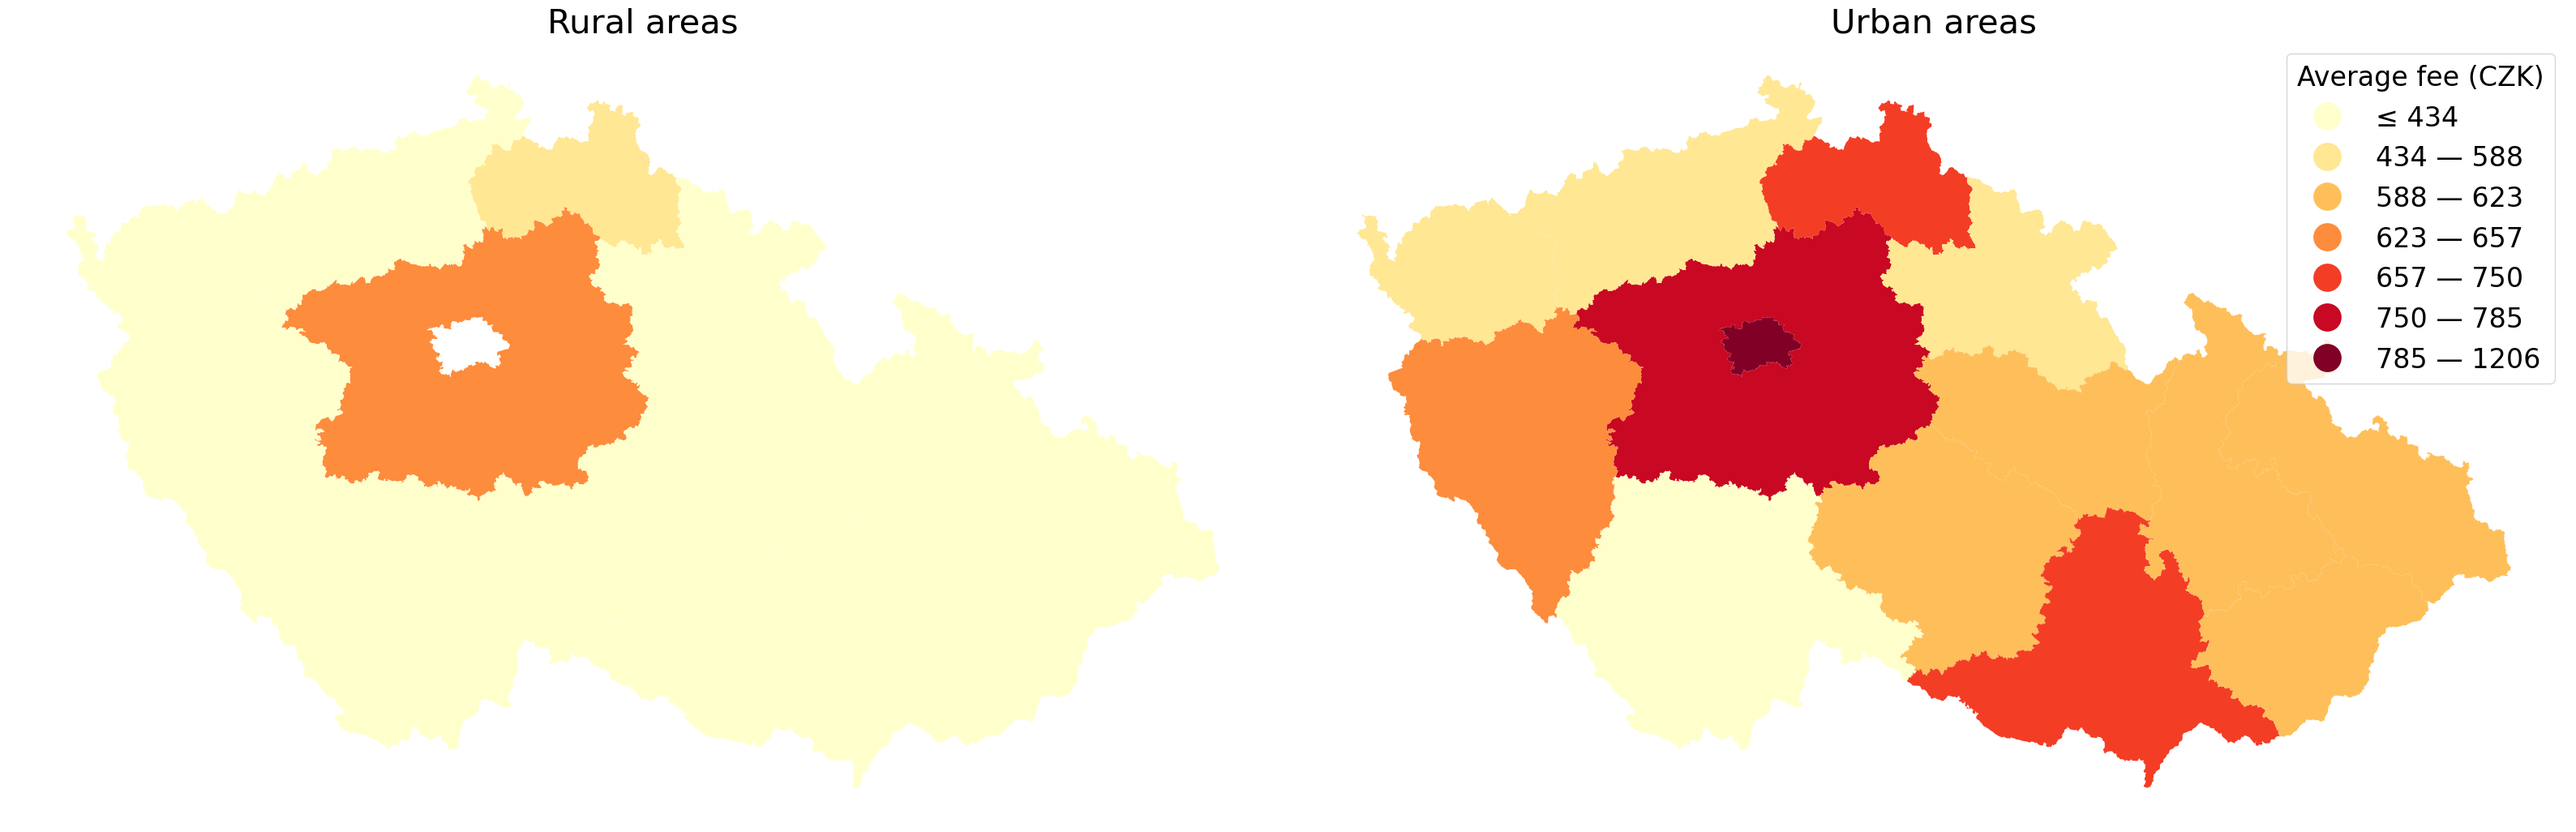

In [97]:

fig, axes = plt.subplots(1, 2, figsize=(32, 10))


venkov.plot(
    column="average_fee",
    ax=axes[0],
    legend=False,
    cmap="YlOrRd",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    legend_kwds={"labels": labels,    "fontsize": 20, "markerscale": 1.5},

    missing_kwds={"color": "white"},
)

axes[0].set_title("Rural areas",fontsize=30)
axes[0].set_axis_off()

# Město
mesto.plot(
    column="average_fee",
    ax=axes[1],
    legend=True,
    cmap="YlOrRd",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    
    
    legend_kwds={"labels": labels,    "fontsize": 24, "markerscale": 2.5,    "title": "Average fee (CZK)", "title_fontsize":24,
},


    missing_kwds={"color": "white"},
    
)

axes[1].set_axis_off()
axes[1].set_title("Urban areas",fontsize=30)
plt.tight_layout()
plt.show()
